In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch as th
import torch.nn.functional as F
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx

/usr/lib/python3/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1)  IMPORT 
# import graph de l'aéroport
chemin_xml = "../data/airportsAndCoordAndPop.graphml"
graph  = nx.read_graphml(chemin_xml)
# conversion du graph et attribution des caractéristiques aux noeuds
data=from_networkx(graph, group_node_attrs=["lon", "lat", "population"])


In [3]:
pays = data['country']
ville = data['city_name']
# décompte des occurrences de chaque pays
#from collections import Counter
#freq = Counter(pays)
#print(freq)  # Output: Counter({'c': 3, 'a': 2, 'b': 1})   

import pandas as pd
lespays=pd.Series(pays).value_counts()

# nombre de connexions  par aéroport
edge=data.edge_index 
nb_connection = edge.size(1)
print(nb_connection)
# nombre de connexions par aéroport

nb_connection_sortantes = pd.Series(edge[0].tolist()).value_counts().rename_axis('airport').reset_index(name='nb_sortantes')
# stat sur les connexions sortantes par aéroport
# hum , j'ai l'impression que le graph n'est pas dirigé: les connexions entrantes et sortantes sont similaires
nb_connection_entrantes = pd.Series(edge[1].tolist()).value_counts().rename_axis('airport').reset_index(name='nb_entrantes')

    



27094


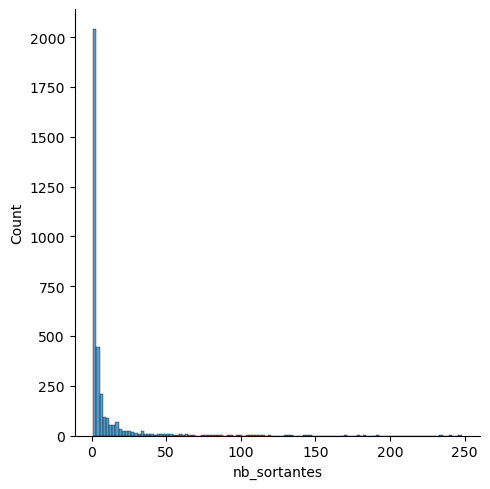

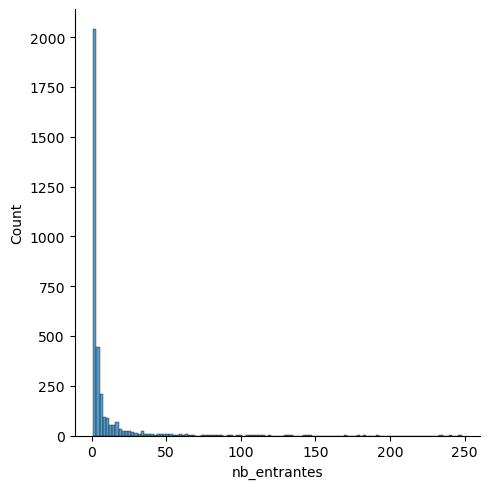

In [4]:
# graph sur les connexions
sns.displot(nb_connection_sortantes,
            x="nb_sortantes")

sns.displot(nb_connection_entrantes,
            x="nb_entrantes")

df_fusionne = pd.merge(nb_connection_sortantes, nb_connection_entrantes, on='airport', how='outer')


In [5]:
for key, item in data:
    print(f'{key} found in data')
    print(item)

edge_index found in data
tensor([[   0,    0,    1,  ..., 3361, 3361, 3362],
        [   1,    2,    0,  ..., 3359, 3362, 3361]])
country found in data
['FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'NEW_ZEALAND', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'USA', 'FRENCH_POLYNESIA', 'CHILE', 'FRENCH_POLYNESIA', 'USA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'NEW_CALEDONIA', 'JAPAN', 'FRENCH_POLYNESIA', 'COOK_ISLANDS', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'JAPAN', 'WALLIS_AND_FUTUNA_ISLANDS', 'FRENCH_POLYNESIA', 'SAMOA', 'NEW_ZEALAND', 'AUSTRALIA', 'ARGENTINA', 'NEW_ZEALAND', 'AUSTRALIA', 'INDONESIA', 'NEW_ZEALAND', 'CHINA', 'NEW_ZEALAND', 'NIUE', 'NEW_ZEALAND', 'NEW_ZEALAND', 'MALAYSIA', 'AUSTRALIA', 'FIJI', 'JAPAN', 'AUSTRALIA', 'NEW_ZEALAND', 'NEW_ZEALAND', 'NEW_ZEALAND', 'AUSTRALIA', 'NEW_ZEALAND', 'NEW_ZEALAND', 'SOUTH_KOREA', 'SINGAPORE', 'AUSTRALIA

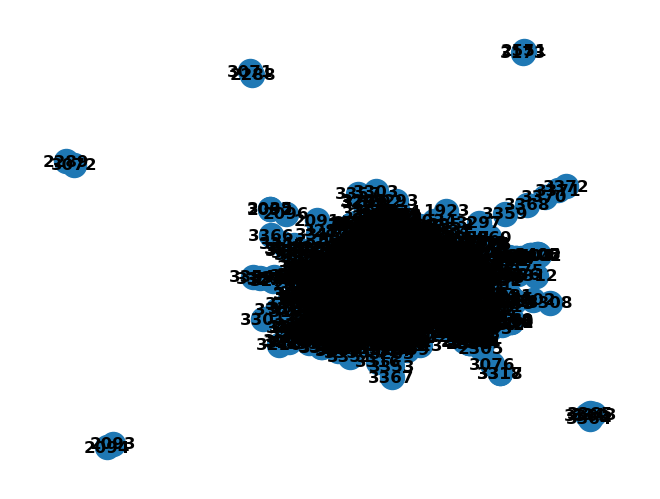

In [6]:

nx.draw(graph, with_labels=True, font_weight='bold')

In [12]:
import copy
x_brut = data.x.float()

# Normalisation : log(1 + population), puis standardisation de chaque colonne
x_log = x_brut.clone()
x_log[:, 2] = th.log1p(x_log[:, 2])
x_normalise = (x_log - x_log.mean(dim=0)) / x_log.std(dim=0)
log_pop = x_normalise[:, 2:3]

# Coordonnées 3D sur la sphère
lon_rad = th.deg2rad(x_brut[:, 0])
lat_rad = th.deg2rad(x_brut[:, 1])
coord_3d = th.stack([
    th.cos(lat_rad) * th.cos(lon_rad),  # x
    th.cos(lat_rad) * th.sin(lon_rad),  # y
    th.sin(lat_rad),                    # z
], dim=1)

# One-hot du pays : chaque pays reçoit un indice (LabelEncoder), puis on crée le vecteur one-hot
indices_pays = th.tensor(LabelEncoder().fit_transform(train_data.country))
pays_one_hot = F.one_hot(indices_pays).float()

features = {
    "normalisées": x_normalise,
    "3D": th.cat([coord_3d, log_pop], dim=1),
    "3D + pays": th.cat([coord_3d, log_pop, pays_one_hot], dim=1),
}

def avec_features(donnees, x):
    # même graphe et mêmes paires à prédire, seules les features des nœuds changent
    donnees_bis = copy.copy(donnees)
    donnees_bis.x = x
    return donnees_bis

colonnes = ["longitude", "latitude", "population"]
print("Features brutes :\n", pd.DataFrame(x_brut.numpy(), columns=colonnes).describe().loc[["mean", "std", "min", "max"]].round(2))
print("\nFeatures normalisées :\n", pd.DataFrame(x_normalise.numpy(), columns=colonnes).describe().loc[["mean", "std", "min", "max"]].round(2))

print()
for nom, x in features.items():
    print(f"{nom} : {x.size(1)} features par aéroport")

# Exemple : -179° et +179° de longitude sont loin en (lon, lat) mais proches en 3D
print()
for lon in [-179.0, 179.0]:
    l = th.deg2rad(th.tensor(lon))
    print(f"lon = {lon:+.0f}°, lat = 0° -> (x, y, z) = ({th.cos(l):.3f}, {th.sin(l):.3f}, 0.000)")

# Pourquoi le pays est utile : part des paires dans le même pays, vraies routes vs paires négatives
print()
for titre, paires in [("vraies routes", test_data.pos_edge_label_index), ("paires négatives", test_data.neg_edge_label_index)]:
    meme_pays = (indices_pays[paires[0]] == indices_pays[paires[1]]).float().mean()
    print(f"Test, {titre} : {meme_pays:.1%} relient deux aéroports du même pays")

Features brutes :
       longitude  latitude   population
mean       0.70     23.02    338077.66
std       96.47     29.33   1262283.25
min     -179.87    -54.82       637.00
max      179.90     78.25  22315474.00

Features normalisées :
       longitude  latitude  population
mean       0.00      0.00        0.00
std        1.00      1.00        1.00
min       -1.87     -2.65       -2.31
max        1.86      1.88        3.46

normalisées : 3 features par aéroport
3D : 4 features par aéroport
3D + pays : 216 features par aéroport

lon = -179°, lat = 0° -> (x, y, z) = (-1.000, -0.017, 0.000)
lon = +179°, lat = 0° -> (x, y, z) = (-1.000, 0.017, 0.000)

Test, vraies routes : 56.4% relient deux aéroports du même pays
Test, paires négatives : 4.4% relient deux aéroports du même pays


In [14]:

data_norm = avec_features(data, features["3D + pays"])

print(data_norm)

Data(edge_index=[2, 27094], country=[3363], city_name=[3363], x=[3363, 216])


In [15]:
#  on divise le set en train , val et test
from turtle import save

from torch import save
from torch_geometric.transforms import RandomLinkSplit

#transform = RandomLinkSplit(is_undirected=True)

transform = RandomLinkSplit(is_undirected=True,split_labels=True)
train_data, val_data, test_data = transform(data_norm)
print(train_data)
print(val_data)
print(test_data)

save(train_data,'../data/train_data_norm.pt')
save(val_data, '../data/val_data_norm.pt')
save(test_data, '../data/test_data_norm.pt')
save(data, '../data/data_norm.pt')
print("sauvegarde terminée")

Data(edge_index=[2, 18968], country=[3363], city_name=[3363], x=[3363, 216], pos_edge_label=[9484], pos_edge_label_index=[2, 9484], neg_edge_label=[9484], neg_edge_label_index=[2, 9484])
Data(edge_index=[2, 18968], country=[3363], city_name=[3363], x=[3363, 216], pos_edge_label=[1354], pos_edge_label_index=[2, 1354], neg_edge_label=[1354], neg_edge_label_index=[2, 1354])
Data(edge_index=[2, 21676], country=[3363], city_name=[3363], x=[3363, 216], pos_edge_label=[2709], pos_edge_label_index=[2, 2709], neg_edge_label=[2709], neg_edge_label_index=[2, 2709])
sauvegarde terminée
